# Movie Genre Classification

### CodSoft Machine Learning Internship

In [1]:
import pandas as pd

movie_rows = []

with open("Genre Classification Dataset/train_data.txt", "r", encoding="utf-8") as file:
    for line in file:
        parts = line.split(" ::: ")

        if len(parts) >= 4:
            movie_rows.append([parts[1], parts[2], parts[3]])

In [2]:
movies = pd.DataFrame(
    movie_rows,
    columns=["title", "genre", "description"]
)

movies.head()

,title,genre,description
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [3]:
print("Dataset Shape:", movies.shape)

print("Total Genres:", movies["genre"].nunique())

Dataset Shape: (54214, 3)
Total Genres: 27


In [4]:
movies["genre"].value_counts().head(10)

genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
Name: count, dtype: int64

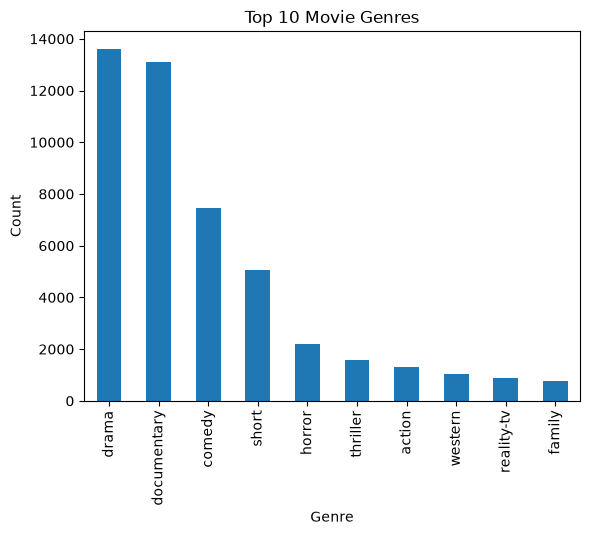

In [5]:
import matplotlib.pyplot as plt

movies["genre"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

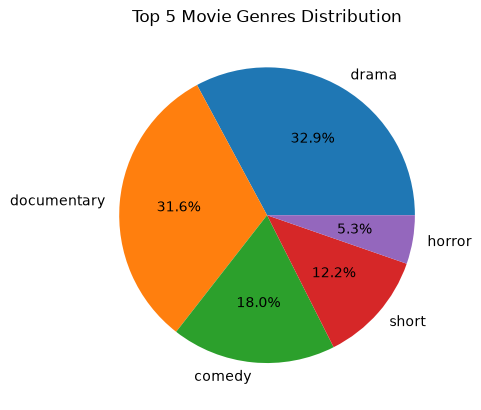

In [6]:
movies["genre"].value_counts().head(5).plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Top 5 Movie Genres Distribution")

plt.ylabel("")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [8]:
movie_text = movies["description"]

movie_genre = movies["genre"]

In [9]:
train_text, test_text, train_genre, test_genre = train_test_split(
    movie_text,
    movie_genre,
    test_size=0.2,
    random_state=42
)

In [10]:
vectorizer = TfidfVectorizer(max_features=10000)

train_text = vectorizer.fit_transform(train_text)

test_text = vectorizer.transform(test_text)

In [11]:
model = LogisticRegression(max_iter=1000)

In [12]:
model.fit(train_text, train_genre)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
predictions = model.predict(test_text)

accuracy = accuracy_score(test_genre, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.5884902702204187


In [14]:
sample_movie = [
    "A group of friends enter a haunted house and face terrifying supernatural events."
]

sample_vector = vectorizer.transform(sample_movie)

result = model.predict(sample_vector)

print("Predicted Genre:", result[0])

Predicted Genre: horror


In [15]:
sample_movie = [
    "A young couple falls in love and struggles to keep their relationship alive."
]

sample_vector = vectorizer.transform(sample_movie)

result = model.predict(sample_vector)

print("Predicted Genre:", result[0])

Predicted Genre: drama
